# Preparación de entorno

In [1]:
# Manejo de archivos y carpetas
import os

# Computación numérica
import numpy as np

# Librería para gráficos
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Gráficos 3D

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [2]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


# Preparar datos

In [6]:
# Librerías
import pandas as pd

# Cargar dataset
data = pd.read_csv("/content/gdrive/MyDrive/SIS420/datasets/datasets_tareas/train.csv")

# ── Transformaciones necesarias ──────────────────────────────────────────────

# 1. time → extraer hora como número entero
data['time_hour'] = data['time'].str.split(':').str[0].astype(int)

# 2. car_value (a-g) → ordinal numérico
car_value_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7}
data['car_value_num'] = data['car_value'].map(car_value_map)

# 3. state → one-hot encoding
state_dummies = pd.get_dummies(data['state'], prefix='state')
data = pd.concat([data, state_dummies], axis=1)

# ── Selección de 25 atributos para X ────────────────────────────────────────
state_cols = list(state_dummies.columns[:5])  # 5 columnas de state

feature_cols = [
    'shopping_pt',       # punto de compra (sesión)
    'record_type',       # 0=cotización, 1=compra
    'day',               # día de la semana
    'time_hour',         # hora de la consulta
    'group_size',        # tamaño del grupo asegurado
    'homeowner',         # es propietario de casa (0/1)
    'car_age',           # edad del vehículo
    'car_value_num',     # valor del auto
    'risk_factor',       # factor de riesgo
    'age_oldest',        # edad del conductor mayor
    'age_youngest',      # edad del conductor menor
    'married_couple',    # pareja casada (0/1)
    'C_previous',        # cobertura C anterior
    'duration_previous', # duración del plan anterior
    'A',                 # opción de cobertura A
    'B',                 # opción de cobertura B
    'C',                 # opción de cobertura C
    'D',                 # opción de cobertura D
    'E',                 # opción de cobertura E
    'F',                 # opción de cobertura F
] + state_cols           # + 5 columnas de state = 25 total

# Manejar valores nulos con la media de cada columna
data_clean = data[feature_cols + ['cost']].copy()

for col in feature_cols:
    if data_clean[col].isnull().any():
        media = data_clean[col].mean()
        data_clean[col] = data_clean[col].fillna(media)
        print(f"  '{col}': nulos reemplazados con media={media:.2f}")

print(f"Nulos restantes: {data_clean.isnull().sum().sum()}")

# Armar X e y como arrays numpy
X = data_clean[feature_cols].values
y = data_clean['cost'].values

# Cantidad de registros
m = y.size
print("\nNúmero de registros:", m)
print("\nPrimeros 10 registros usados en la regresión:\n")

# Imprimir atributos + variable objetivo
print(data_clean[feature_cols + ['cost']].head(10))

  'car_value_num': nulos reemplazados con media=5.33
  'risk_factor': nulos reemplazados con media=2.56
  'C_previous': nulos reemplazados con media=2.44
  'duration_previous': nulos reemplazados con media=6.00
Nulos restantes: 0

Número de registros: 665249

Primeros 10 registros usados en la regresión:

   shopping_pt  record_type  day  time_hour  group_size  homeowner  car_age  \
0            1            0    0          8           2          0        2   
1            2            0    0          8           2          0        2   
2            3            0    0          8           2          0        2   
3            4            0    0          8           2          0        2   
4            5            0    0         11           2          0        2   
5            6            0    0         11           2          0        2   
6            7            0    0         11           2          0        2   
7            8            0    0         12           2      

# Función de Normalización

In [7]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1]) # Número de columnas (atributos)
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # Calcula la media por columna mu = [media1, media2, media3, ..., media11]
    sigma = np.std(X, axis = 0) # Calcula desviación estándar sigma = [std1, std2, std3, ..., std11]
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [9]:
# Aplicar la función
X = X.astype(float)
X_norm, mu, sigma = featureNormalize(X)

# Datos originales
#print(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

# Datos normalizados
#print(X_norm)

Media calculada: [4.21996576e+00 1.45823594e-01 1.96942949e+00 1.26664482e+01
 1.23478427e+00 5.36229292e-01 8.13943651e+00 5.33264305e+00
 2.56399604e+00 4.49924028e+01 4.25775882e+01 2.09781601e-01
 2.44471787e+00 6.00377395e+00 9.27545926e-01 4.54235933e-01
 2.27526535e+00 2.45429907e+00 4.45192702e-01 1.16276763e+00
 3.54153107e-02 1.57234359e-02 3.66915245e-02 2.90913628e-02
 5.63398066e-03]
Desviación estandar calculada: [ 2.39436697  0.35292928  1.45346941  2.71353723  0.46103532  0.49868571
  5.7645937   1.04554291  0.88829598 17.40342688 17.46041925  0.40715265
  1.01994219  4.61449314  0.59522094  0.49790125  0.99079748  0.75395228
  0.49698708  0.94359308  0.18482713  0.12440341  0.18800334  0.16806265
  0.07484811]


# Intersección Columnas de unos

In [10]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Imprimir y ver la columna de unos
# print(X)

print("Dimensión de X:", X.shape)

Dimensión de X: (665249, 26)


# Descenso de Gradiente

In [11]:
def computeCostMulti(X, y, theta):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [12]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# Coeficiente de aprendizaje

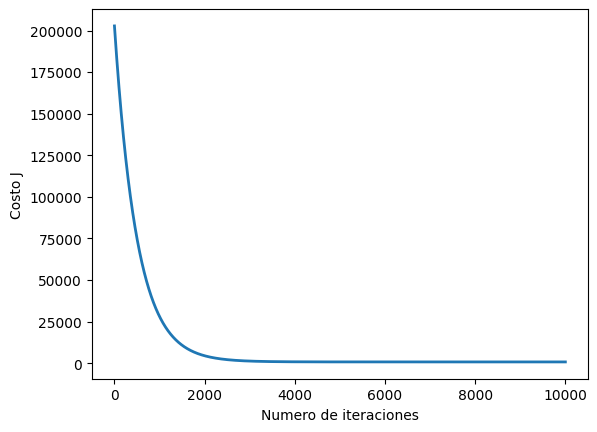

theta calculado por el descenso por el gradiente: [ 6.35756288e+02  1.40199185e+00 -1.19198688e+00  2.38531069e-01
 -1.19932669e+00  3.13184288e+00 -7.14658262e+00 -7.20393430e+00
  1.43146428e+00  3.01937879e+00  2.47433298e+00 -8.47744634e+00
 -4.07648546e+00 -4.92406048e+00 -4.69224774e+00  1.17008582e+01
  1.92736054e-01  2.50646722e-01 -1.03435669e+00  8.62013491e+00
 -2.78905145e+00 -1.85542154e+00 -7.23704458e-01 -1.20740575e+00
  8.41778573e-01  1.53766477e+00]


In [14]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])

# Ejecutar descenso de gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# 100 Predicciones con Regresión Polinómica

In [15]:
# 100 predicciones

# Tomar 100 muestras aleatorias del dataset
indices = np.random.choice(m, 100, replace=False)
X_muestra = data_clean[feature_cols].values[indices].astype(float)
y_real = y[indices]

# Normalizar con la misma mu y sigma del entrenamiento
X_muestra_norm = (X_muestra - mu) / sigma

# Agregar columna de unos (término de intersección)
X_muestra_norm = np.concatenate([np.ones((100, 1)), X_muestra_norm], axis=1)

# Realizar predicciones
predicciones = X_muestra_norm.dot(theta)

# Mostrar resultados
print('{:>10s}{:>15s}{:>15s}{:>15s}'.format('Muestra', 'Predicción', 'Real', 'Diferencia'))
print('-' * 55)
for i in range(100):
    diff = predicciones[i] - y_real[i]
    print('{:>10d}{:>15.2f}{:>15.2f}{:>15.2f}'.format(i+1, predicciones[i], y_real[i], diff))

# Error promedio
error_promedio = np.mean(np.abs(predicciones - y_real))
print(f"\nError absoluto promedio: {error_promedio:.2f}")
print(f"Costo en las 100 muestras: {computeCostMulti(X_muestra_norm, y_real, theta):.2f}")

   Muestra     Predicción           Real     Diferencia
-------------------------------------------------------
         1         644.82         698.00         -53.18
         2         656.23         683.00         -26.77
         3         623.95         589.00          34.95
         4         663.91         595.00          68.91
         5         631.37         692.00         -60.63
         6         680.92         718.00         -37.08
         7         630.68         671.00         -40.32
         8         628.68         638.00          -9.32
         9         620.24         618.00           2.24
        10         646.78         682.00         -35.22
        11         668.89         641.00          27.89
        12         674.73         759.00         -84.27
        13         631.83         654.00         -22.17
        14         626.23         606.00          20.23
        15         616.91         676.00         -59.09
        16         685.39         760.00        

# Ecuación Normal

In [16]:
# Cargar datos
data_en = data_clean[feature_cols + ['cost']].copy()

X_en = data_en[feature_cols].values.astype(float)
y_en = data_en['cost'].values
m_en = y_en.size

print(m_en)

X_en = np.concatenate([np.ones((m_en, 1)), X_en], axis=1)

665249


In [17]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [18]:
# Calcula los parametros con la ecuación de la normal
theta_normal = normalEqn(X_en, y_en)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

# Estimar el costo para un ejemplo con valores específicos
# [1, shopping_pt, record_type, day, time_hour, group_size, homeowner, car_age,
#  car_value_num, risk_factor, age_oldest, age_youngest, married_couple,
#  C_previous, duration_previous, A, B, C, D, E, F, state_col1..5]

X_array = [1, 2, 0, 0, 8, 2, 0, 3, 5, 2, 45, 30, 1, 2, 6, 1, 0, 2, 2, 1, 2, 0, 1, 0, 0, 1]
cost_pred = np.dot(X_array, theta_normal)

print('Costo predecido para el ejemplo dado (usando la ecuación de la normal): ${:.0f}'.format(cost_pred))

Theta calculado a partir de la ecuación de la normal: [ 6.51724281e+02  5.75497011e-01 -3.38010023e+00  1.53214227e-01
 -4.46150554e-01  1.66846556e+00 -1.46357428e+01 -1.24852761e+00
  1.43863569e+00  3.39411582e+00  5.26464303e-01 -8.60215483e-01
 -7.58001695e+00 -4.86292728e+00 -1.04331840e+00  1.97854305e+01
  3.24429585e-01  4.36638652e-01 -1.46334669e+00  1.73346070e+01
 -2.97733029e+00 -1.00614807e+01 -5.81822553e+00 -6.33149729e+00
  4.78825192e+00  2.06291025e+01]
Costo predecido para el ejemplo dado (usando la ecuación de la normal): $681


# 100 Predicciones con Ecuación Normal

In [19]:
# 100 predicciones con ecuación normal

# Tomar 100 muestras aleatorias del dataset
indices = np.random.choice(m_en, 100, replace=False)
X_muestra = X_en[indices]
y_real = y_en[indices]

# Realizar predicciones (X_en ya tiene la columna de unos, no necesita normalización)
predicciones = X_muestra.dot(theta_normal)

# Mostrar resultados
print('{:>10s}{:>15s}{:>15s}{:>15s}'.format('Muestra', 'Predicción', 'Real', 'Diferencia'))
print('-' * 55)
for i in range(100):
    diff = predicciones[i] - y_real[i]
    print('{:>10d}{:>15.2f}{:>15.2f}{:>15.2f}'.format(i+1, predicciones[i], y_real[i], diff))

# Error promedio
error_promedio = np.mean(np.abs(predicciones - y_real))
print(f"\nError absoluto promedio: {error_promedio:.2f}")
print(f"Costo en las 100 muestras: {computeCostMulti(X_muestra, y_real, theta_normal):.2f}")

   Muestra     Predicción           Real     Diferencia
-------------------------------------------------------
         1         667.39         666.00           1.39
         2         657.89         639.00          18.89
         3         636.78         615.00          21.78
         4         649.44         644.00           5.44
         5         655.99         599.00          56.99
         6         672.52         617.00          55.52
         7         674.24         633.00          41.24
         8         628.97         602.00          26.97
         9         590.59         669.00         -78.41
        10         661.68         601.00          60.68
        11         644.67         628.00          16.67
        12         653.97         673.00         -19.03
        13         670.14         703.00         -32.86
        14         656.53         660.00          -3.47
        15         646.29         714.00         -67.71
        16         660.65         622.00        